### IMDB report tables generator


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from transformers import AutoTokenizer
import matplotlib.pyplot as plt


all_results = pd.read_csv("project_outputs/tables/all_model_results.csv")
ablation_results = pd.read_csv("project_outputs/tables/ablation_results.csv")

print("Loaded")
print()
print("all_model_results shape:", all_results.shape)
print("ablation_results shape:", ablation_results.shape)


c:\Users\psadi\anaconda3\envs\ds6050\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded

all_model_results shape: (104, 11)
ablation_results shape: (12, 9)


### 1 Dataset length statistics

load the IMDB dataset directly


In [2]:

texts = None

try:
    from datasets import load_dataset
    ds = load_dataset("imdb")
    texts = list(ds["train"]["text"]) + list(ds["test"]["text"])
    print(f"Loaded IMDB directly from datasets: {len(texts):,} reviews")
except Exception as e:
    print("Direct dataset load failed.")
    print("Replace this block with your runner.py dataset loading code.")
    print("Error:", e)



Loaded IMDB directly from datasets: 50,000 reviews


In [3]:
if texts is None:
    raise ValueError("Set `texts` first using your runner.py loading code or the datasets package.")


# BiLSTM length table: word-based
word_lengths = [len(str(t).split()) for t in texts]

bilstm_length_stats = pd.DataFrame([{
    "Model family": "BiLSTM",
    "Length type": "Words",
    "Min": int(np.min(word_lengths)),
    "Median": int(np.median(word_lengths)),
    "Mean": round(float(np.mean(word_lengths)), 2),
    "Max": int(np.max(word_lengths)),
}])

# RoBERTa length table: tokenizer-based
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
token_lengths = [len(tokenizer.encode(str(t), truncation=False)) for t in texts]

roberta_length_stats = pd.DataFrame([{
    "Model family": "RoBERTa",
    "Length type": "RoBERTa tokens",
    "Min": int(np.min(token_lengths)),
    "Median": int(np.median(token_lengths)),
    "Mean": round(float(np.mean(token_lengths)), 2),
    "Max": int(np.max(token_lengths)),
}])

display(bilstm_length_stats)
display(roberta_length_stats)

bilstm_length_stats.to_csv("project_outputs/tables/bilstm_length_stats.csv", index=False)
roberta_length_stats.to_csv("project_outputs/tables/roberta_length_stats.csv", index=False)

Token indices sequence length is longer than the specified maximum sequence length for this model (680 > 512). Running this sequence through the model will result in indexing errors


,Model family,Length type,Min,Median,Mean,Max
0,BiLSTM,Words,4,173,231.16,2470


,Model family,Length type,Min,Median,Mean,Max
0,RoBERTa,RoBERTa tokens,10,222,298.25,3099


In [4]:
def length_bin(x):
    if x < 128:
        return "short"
    elif x <= 512:
        return "medium"
    else:
        return "long"

def make_bin_table(lengths, model_name):
    df = (
        pd.Series(lengths, name="length")
        .map(length_bin)
        .value_counts()
        .reindex(["short", "medium", "long"])
        .rename_axis("Length bin")
        .reset_index(name="Review count")
    )

    df["Percent"] = (100 * df["Review count"] / df["Review count"].sum()).round(2)
    df["Model"] = model_name
    return df

# BiLSTM (word-based)
bilstm_bins = make_bin_table(word_lengths, "BiLSTM (words)")

# RoBERTa (token-based)
roberta_bins = make_bin_table(token_lengths, "RoBERTa (tokens)")

display(bilstm_bins)
display(roberta_bins)

# Optional save
bilstm_bins.to_csv("project_outputs/tables/bilstm_length_bins.csv", index=False)
roberta_bins.to_csv("project_outputs/tables/roberta_length_bins.csv", index=False)

,Length bin,Review count,Percent,Model
0,short,12929,25.86,BiLSTM (words)
1,medium,33377,66.75,BiLSTM (words)
2,long,3694,7.39,BiLSTM (words)


,Length bin,Review count,Percent,Model
0,short,5752,11.50,RoBERTa (tokens)
1,medium,37643,75.29,RoBERTa (tokens)
2,long,6605,13.21,RoBERTa (tokens)


### 2 Main model comparison table

- Logistic Regression
- BiLSTM_T128_head+tail
- RoBERTa_T512_head-only


In [5]:
primary_models = [
    "Logistic Regression",
    "BiLSTM_T128_head+tail",
    "RoBERTa_T512_head-only",
]

overall_test_table = (
    all_results[
        (all_results["split"] == "test") &
        (all_results["metric_scope"] == "overall") &
        (all_results["model"].isin(primary_models))
    ][["model", "accuracy", "f1", "auc", "training_time_seconds", "inference_time_seconds"]]
    .copy()
    .sort_values("model")
)

overall_test_table = overall_test_table.rename(columns={
    "model": "Model",
    "accuracy": "Accuracy",
    "f1": "F1",
    "auc": "AUC",
    "training_time_seconds": "Train time (s)",
    "inference_time_seconds": "Inference time (s)",
})

for col in ["Accuracy", "F1", "AUC", "Train time (s)", "Inference time (s)"]:
    overall_test_table[col] = overall_test_table[col].round(4)

overall_test_table


,Model,Accuracy,F1,AUC,Train time (s),Inference time (s)
20,BiLSTM_T128_head+tail,0.8330,0.8364,0.9122,23.7084,2.2924
4,Logistic Regression,0.8903,0.8907,0.9580,6.7852,4.5165
92,RoBERTa_T512_head-only,0.9309,0.9290,0.9827,301.9303,123.1751


### 3 F1 by review length group



In [6]:
f1_by_length_table = (
    all_results[
        (all_results["split"] == "test") &
        (all_results["metric_scope"] == "by_length") &
        (all_results["model"].isin(primary_models))
    ][["model", "length_bin", "f1"]]
    .copy()
    .pivot(index="model", columns="length_bin", values="f1")
    .reindex(primary_models)
    [["short", "medium", "long"]]
    .reset_index()
)

f1_by_length_table.columns = ["Model", "Short F1", "Medium F1", "Long F1"]
for col in ["Short F1", "Medium F1", "Long F1"]:
    f1_by_length_table[col] = f1_by_length_table[col].round(4)

f1_by_length_table


,Model,Short F1,Medium F1,Long F1
0,Logistic Regression,0.9025,0.8856,0.8902
1,BiLSTM_T128_head+tail,0.8758,0.8253,0.7873
2,RoBERTa_T512_head-only,0.9422,0.9278,0.8883


### 4 Ablation tables



In [7]:
bilstm_ablation = (
    ablation_results[ablation_results["model_family"] == "BiLSTM"]
    [["max_length", "truncation_strategy", "accuracy", "f1", "auc", "training_time_seconds", "inference_time_seconds"]]
    .copy()
    .sort_values(["max_length", "truncation_strategy"])
    .rename(columns={
        "max_length": "Max length",
        "truncation_strategy": "Truncation",
        "accuracy": "Accuracy",
        "f1": "F1",
        "auc": "AUC",
        "training_time_seconds": "Train time (s)",
        "inference_time_seconds": "Inference time (s)",
    })
)

for col in ["Accuracy", "F1", "AUC", "Train time (s)", "Inference time (s)"]:
    bilstm_ablation[col] = bilstm_ablation[col].round(4)

bilstm_ablation


,Max length,Truncation,Accuracy,F1,AUC,Train time (s),Inference time (s)
1,128,head+tail,0.8330,0.8364,0.9122,23.7084,2.2924
0,128,head-only,0.7921,0.7807,0.8740,23.0885,2.2391
3,256,head+tail,0.6554,0.6452,0.7213,28.0804,2.6194
2,256,head-only,0.8154,0.8165,0.8868,27.5057,2.5911
5,512,head+tail,0.8135,0.8201,0.8807,37.0601,3.2756
4,512,head-only,0.7915,0.7854,0.8703,37.1522,3.3822


In [8]:
roberta_ablation = (
    ablation_results[ablation_results["model_family"] == "RoBERTa"]
    [["max_length", "truncation_strategy", "accuracy", "f1", "auc", "training_time_seconds", "inference_time_seconds"]]
    .copy()
    .sort_values(["max_length", "truncation_strategy"])
    .rename(columns={
        "max_length": "Max length",
        "truncation_strategy": "Truncation",
        "accuracy": "Accuracy",
        "f1": "F1",
        "auc": "AUC",
        "training_time_seconds": "Train time (s)",
        "inference_time_seconds": "Inference time (s)",
    })
)

for col in ["Accuracy", "F1", "AUC", "Train time (s)", "Inference time (s)"]:
    roberta_ablation[col] = roberta_ablation[col].round(4)

roberta_ablation


,Max length,Truncation,Accuracy,F1,AUC,Train time (s),Inference time (s)
7,128,head+tail,0.9290,0.9310,0.9789,100.1673,35.8186
6,128,head-only,0.8823,0.8764,0.9596,100.4262,39.1397
9,256,head+tail,0.9310,0.9278,0.9878,161.3458,62.0927
8,256,head-only,0.9138,0.9089,0.9798,161.3652,65.4403
11,512,head+tail,0.9326,0.9358,0.9885,306.4310,119.1493
10,512,head-only,0.9309,0.9290,0.9827,301.9303,123.1751


### 5 Compact efficiency table


In [9]:
efficiency_table = overall_test_table[["Model", "Train time (s)", "Inference time (s)"]].copy()
efficiency_table


,Model,Train time (s),Inference time (s)
20,BiLSTM_T128_head+tail,23.7084,2.2924
4,Logistic Regression,6.7852,4.5165
92,RoBERTa_T512_head-only,301.9303,123.1751


### 6 Optional: export all tables to CSV and LaTeX



In [10]:
out_dir = Path("project_outputs/report_tables")
out_dir.mkdir(exist_ok=True)

length_stats = pd.concat(
    [bilstm_length_stats, roberta_length_stats],
    ignore_index=True
)

bin_counts = pd.DataFrame({
    "Length bin": ["Short", "Medium", "Long"],
    "Review count": [12929, 33377, 3694],
    "Percent": [25.86, 66.75, 7.39]
})

tables = {
    "length_stats": length_stats,
    "bin_counts": bin_counts,
    "overall_test_table": overall_test_table,
    "f1_by_length_table": f1_by_length_table,
    "bilstm_ablation_table": bilstm_ablation,
    "roberta_ablation_table": roberta_ablation,
    "efficiency_table": efficiency_table,
}

for name, df in tables.items():
    csv_path = out_dir / f"{name}.csv"
    tex_path = out_dir / f"{name}.tex"
    
    df.to_csv(csv_path, index=False)
    
    with open(tex_path, "w", encoding="utf-8") as f:
        f.write(df.to_latex(index=False, escape=False))
    
    print(f"Saved {csv_path.resolve()}")
    print(f"Saved {tex_path.resolve()}")


Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\length_stats.csv
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\length_stats.tex
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\bin_counts.csv
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\bin_counts.tex
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\overall_test_table.csv
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\overall_test_table.tex
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\f1_by_length_table.csv
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\f1_by_length_table.tex
Saved C:\Users\psadi

In [11]:
out_dir = Path("project_outputs/report_tables")
out_dir.mkdir(parents=True, exist_ok=True)

tables = {
    "length_stats": length_stats,
    "bin_counts": bin_counts,
    "overall_test_table": overall_test_table,
    "f1_by_length_table": f1_by_length_table,
    "bilstm_ablation_table": bilstm_ablation,
    "roberta_ablation_table": roberta_ablation,
    "efficiency_table": efficiency_table,
}


for name, df in tables.items():
    csv_path = out_dir / f"{name}.csv"
    tex_path = out_dir / f"{name}.tex"
    
    df.to_csv(csv_path, index=False, float_format="%.4f")
    
    with open(tex_path, "w", encoding="utf-8") as f:
        f.write(df.to_latex(
            index=False,
            escape=False,
            float_format="%.4f",
            caption=name.replace("_", " ").title(),
            label=f"tab:{name}"
        ))
    
    print(f"Saved {csv_path.resolve()}")
    print(f"Saved {tex_path.resolve()}")

Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\length_stats.csv
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\length_stats.tex
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\bin_counts.csv
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\bin_counts.tex
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\overall_test_table.csv
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\overall_test_table.tex
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\f1_by_length_table.csv
Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_tables\f1_by_length_table.tex
Saved C:\Users\psadi

In [12]:
print(f1_by_length_table.columns)
display(f1_by_length_table.head())

Index(['Model', 'Short F1', 'Medium F1', 'Long F1'], dtype='str')


,Model,Short F1,Medium F1,Long F1
0,Logistic Regression,0.9025,0.8856,0.8902
1,BiLSTM_T128_head+tail,0.8758,0.8253,0.7873
2,RoBERTa_T512_head-only,0.9422,0.9278,0.8883


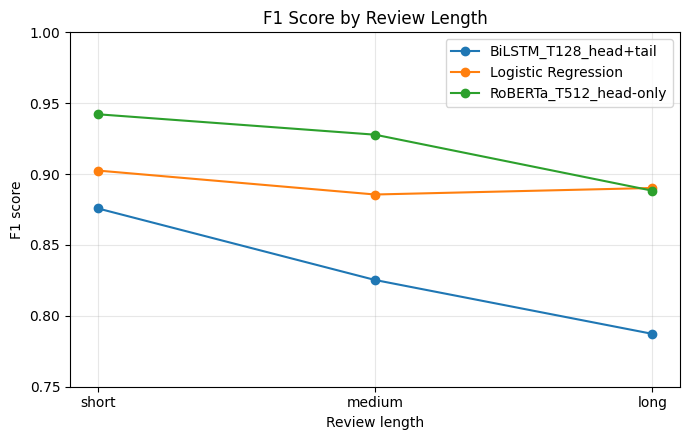

In [13]:
fig_dir = Path("project_outputs/report_figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plot_df = f1_by_length_table.melt(
    id_vars="Model",
    value_vars=["Short F1", "Medium F1", "Long F1"],
    var_name="Review Length",
    value_name="F1"
)

plot_df["Review Length"] = (
    plot_df["Review Length"]
    .str.replace(" F1", "", regex=False)
    .str.lower()
)

order = {"short": 0, "medium": 1, "long": 2}
plot_df["order"] = plot_df["Review Length"].map(order)
plot_df = plot_df.sort_values(["Model", "order"])

plt.figure(figsize=(7, 4.5))

for model, group in plot_df.groupby("Model"):
    plt.plot(
        group["Review Length"],
        group["F1"],
        marker="o",
        label=model
    )

plt.xlabel("Review length")
plt.ylabel("F1 score")
plt.title("F1 Score by Review Length")
plt.ylim(0.75, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(fig_dir / "f1_by_review_length.png", dpi=300, bbox_inches="tight")
plt.savefig(fig_dir / "f1_by_review_length.pdf", bbox_inches="tight")

plt.show()

In [14]:
print(f1_by_length_table)

                    Model  Short F1  Medium F1  Long F1
0     Logistic Regression    0.9025     0.8856   0.8902
1   BiLSTM_T128_head+tail    0.8758     0.8253   0.7873
2  RoBERTa_T512_head-only    0.9422     0.9278   0.8883


In [15]:
print(overall_test_table)

                     Model  Accuracy      F1     AUC  Train time (s)  \
20   BiLSTM_T128_head+tail    0.8330  0.8364  0.9122         23.7084   
4      Logistic Regression    0.8903  0.8907  0.9580          6.7852   
92  RoBERTa_T512_head-only    0.9309  0.9290  0.9827        301.9303   

    Inference time (s)  
20              2.2924  
4               4.5165  
92            123.1751  


In [18]:
tex_path = fig_dir / "f1_by_review_length.tex"

latex_code = r"""
\begin{figure}[htbp]
    \centering
    \includegraphics[width=0.85\linewidth]{figures/f1_by_review_length.png}
    \caption{F1 score by review length for each model. Performance declines with increasing review length, with the largest degradation observed for the BiLSTM, while RoBERTa remains the most robust.}
    \label{fig:f1_by_review_length}
\end{figure}
"""

with open(tex_path, "w", encoding="utf-8") as f:
    f.write(latex_code.strip())

print(f"Saved {tex_path.resolve()}")

Saved C:\Users\psadi\OneDrive\Desktop\MSDS\DS 6050\DS6050-imdb_sentiment\project_outputs\report_figures\f1_by_review_length.tex


In [19]:
from dataset_utils import load_imdb_data
import os

TABLES_DIR = "project_outputs/report_tables"
os.makedirs(TABLES_DIR, exist_ok=True)

train_df, val_df, test_df = load_imdb_data(
    validation_size=5000,
    random_state=42
)

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

In [20]:
results_df = pd.read_csv("project_outputs/tables/all_model_results.csv")

logreg_length = results_df[
    (results_df["model"] == "Logistic Regression") &
    (results_df["split"] == "test") &
    (results_df["metric_scope"] == "by_length")
].copy()

logreg_length["length_bin"] = pd.Categorical(
    logreg_length["length_bin"],
    categories=["short", "medium", "long"],
    ordered=True
)

logreg_length = logreg_length.sort_values("length_bin")

logreg_table = logreg_length[["length_bin", "accuracy", "f1", "auc"]].rename(columns={
    "length_bin": "Length bin",
    "accuracy": "Accuracy",
    "f1": "F1",
    "auc": "AUC",
})

latex = logreg_table.to_latex(
    index=False,
    escape=False,
    float_format="%.4f",
    caption="Logistic Regression performance by review length on the test set.",
    label="tab:logreg_length_performance"
)

print(latex)

with open(os.path.join(TABLES_DIR, "logreg_length_performance.tex"), "w") as f:
    f.write(latex)

\begin{table}
\caption{Logistic Regression performance by review length on the test set.}
\label{tab:logreg_length_performance}
\begin{tabular}{lrrr}
\toprule
Length bin & Accuracy & F1 & AUC \\
\midrule
short & 0.8981 & 0.9025 & 0.9617 \\
medium & 0.8879 & 0.8856 & 0.9568 \\
long & 0.8833 & 0.8902 & 0.9526 \\
\bottomrule
\end{tabular}
\end{table}

